# Computer Exercise 14.4 — Problem 3

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **단원**: 14.4 Transfer Case Study — *Warm-starting hyperparameter search across domains*
> **풀이 일자**: 2026-07-04 · **언어**: 한국어 (그래프 라벨은 영문)

파이프라인의 마지막 손잡이인 **하이퍼파라미터**를 새 도메인에서 다시 튜닝한다. 핵심 아이디어는
source에서 얻은 평가 이력을 GP 사전지식으로 재사용하는 **warm-start 베이지안 최적화(BO)** 다.
도메인이 비슷하면 **양의 전이**, 너무 다르면 **음의 전이**가 일어남을 함께 보인다.

## 1. 문제 (원문)

> **3.** Hyperparameters tuned on a source domain are transferred to a target domain by **warm-starting**
> a Gaussian-process Bayesian optimizer with the source evaluations. On a fixed evaluation budget, compare
> grid search, random search, cold-start BO, and warm-start BO for (i) a target whose optimum is **near** the
> source optimum and (ii) a target whose optimum is **far** from it. Track the simple regret versus the number
> of target evaluations and discuss positive versus negative transfer.

### 한국어 풀이용 정리
- 2차원 하이퍼파라미터 공간 $[0,1]^2$ 에서 검증오차 목적함수를 최소화한다.
- source 목적함수 $g_S$ 에서 얻은 평가점을 GP에 미리 넣어 target BO를 **warm-start** 한다.
- **grid / random / cold-BO / warm-BO** 를 고정 예산에서 비교하고, 최적점이 가까운(near)·먼(far) 두 target으로 **양·음의 전이**를 본다.

## 2. 수학적 배경

### 2.1 가우시안 과정(GP) 대리모형
관측 $\{(x_i,y_i)\}$ 과 RBF 커널 $k(x,x')=s\exp(-\|x-x'\|^2/2\ell^2)$ 로부터 사후평균·분산:
$$\mu(x_\star)=\bar y+k_\star^\top(K+\eta I)^{-1}(y-\bar y),\qquad
\sigma^2(x_\star)=k(x_\star,x_\star)-k_\star^\top(K+\eta I)^{-1}k_\star.$$

### 2.2 기대개선(EI) 획득함수 — 최소화 버전
현재 최선값 $y^{+}=\min_i y_i$ 에 대해
$$\mathrm{EI}(x)=\mathbb E[(y^{+}-Y(x))_{+}]=(y^{+}-\mu)\,\Phi(Z)+\sigma\,\phi(Z),\quad Z=\frac{y^{+}-\mu-\xi}{\sigma},$$
다음 평가점은 $x_{n+1}=\arg\max_x \mathrm{EI}(x)$. ($\Phi,\phi$ 는 표준정규 CDF·PDF; 여기선 `math.erf` 로 구현.)

### 2.3 전이(warm-start)
source 평가 $\{(x^S_j,y^S_j)\}$ 를 GP의 초기 관측으로 넣으면 target 탐색 초반부터 유망 영역을 가리킨다.
$$\boxed{\;\text{유사하면 warm-start가 초기 regret을 크게 낮춘다(양의 전이).}\ \text{너무 다르면 잘못된 영역에 갇혀 최종 regret이 나빠진다(음의 전이).}\;}$$
성능척도는 **단순 후회(simple regret)** $r_t = \big(\min_{i\le t} y_i\big) - \min_x g(x)$.

## 3. 풀이 흐름

1. **목적함수 정의**: source $g_S$, target-near $g_{T}^{\text{near}}$, target-far $g_{T}^{\text{far}}$ (최적점 위치만 이동).
2. **GP·EI 구현**: RBF 커널 사후분포, `math.erf` 기반 $\Phi,\phi$, EI 최대화(후보격자 pool).
3. **탐색기 구현**: grid / random / cold-BO / warm-BO. warm-BO는 source 격자 평가를 초기 관측으로 주입.
4. **전역최소 산출**: 조밀격자로 각 target의 $\min g$ 계산 → regret 기준.
5. **실험**: 예산 $=36$ target 평가에서 네 방법을 near·far 두 시나리오로 실행(무작위성은 시드 평균).
6. **표·수렴곡선**: 평가수 대비 simple regret(로그축).
7. **해석**: 양의 전이 vs 음의 전이, 차원/유사도가 주는 시사점.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from math import erf, sqrt, pi

# ---- 하이퍼파라미터 목적함수 (작을수록 좋은 검증오차) ----
def g_source(P):
    x, y = P[..., 0], P[..., 1]
    return np.sin(3*x)*np.cos(3*y) + (x-0.30)**2 + (y-0.70)**2
def g_target_near(P):            # 최적점이 source와 가까움 -> 양의 전이 기대
    x, y = P[..., 0], P[..., 1]
    return np.sin(3*x)*np.cos(3*y) + (x-0.40)**2 + (y-0.60)**2
def g_target_far(P):             # 최적점이 반대편 -> 음의 전이 위험
    x, y = P[..., 0], P[..., 1]
    return np.sin(3*x)*np.cos(3*y) + (x-0.85)**2 + (y-0.15)**2

# ---- GP (RBF) ----
def rbf(A, B, l=0.18, s=1.0):
    d2 = np.sum(A**2,1)[:,None] + np.sum(B**2,1)[None,:] - 2*A@B.T
    return s*np.exp(-0.5*np.clip(d2,0,None)/l**2)
def gp_post(Xtr, ytr, Xte, l=0.18, s=1.0, noise=1e-3):
    K = rbf(Xtr,Xtr,l,s) + noise*np.eye(len(Xtr))
    L = np.linalg.cholesky(K)
    mean = ytr.mean()
    al = np.linalg.solve(L.T, np.linalg.solve(L, ytr-mean))
    Ks = rbf(Xtr,Xte,l,s)
    mu = mean + Ks.T@al
    v  = np.linalg.solve(L, Ks)
    var = np.clip(np.diag(rbf(Xte,Xte,l,s)) - np.sum(v**2,0), 1e-12, None)
    return mu, var

_erf = np.vectorize(erf)
def ncdf(z): return 0.5*(1+_erf(z/np.sqrt(2)))
def npdf(z): return np.exp(-0.5*z**2)/np.sqrt(2*pi)
def EI(mu, var, ybest, xi=0.01):
    sd = np.sqrt(var); imp = ybest - mu - xi; Z = imp/sd
    return imp*ncdf(Z) + sd*npdf(Z)

# 획득함수 최대화용 후보 격자(pool)
_ax = np.linspace(0,1,41)
pool = np.array([[a,b] for a in _ax for b in _ax])
print("pool size:", pool.shape)

pool size: (1681, 2)


In [2]:
def run_bo(gfun, budget, warm_X=None, warm_y=None, n_init=4, seed=0):
    r = np.random.default_rng(seed)
    tX = np.empty((0,2)); ty = np.empty(0)          # target 평가(예산 소모)
    if warm_X is None:                              # cold: 무작위 초기설계
        tX = r.uniform(0,1,(n_init,2)); ty = gfun(tX)
    while len(ty) < budget:
        if warm_X is None:
            X, y = tX, ty
        else:
            X = np.vstack([warm_X, tX]) if len(tX) else warm_X
            y = np.append(warm_y, ty)
        mu, var = gp_post(X, y, pool)
        ei = EI(mu, var, y.min())
        if len(tX):                                 # 이미 뽑은 점 제외
            dmin = np.min(np.sum((pool[:,None,:]-tX[None,:,:])**2, 2), 1)
            ei = np.where(dmin < 1e-9, -np.inf, ei)
        xn = pool[np.argmax(ei)][None,:]
        tX = np.vstack([tX, xn]); ty = np.append(ty, gfun(xn))
    return np.minimum.accumulate(ty[:budget])

def run_random(gfun, budget, seed=0):
    r = np.random.default_rng(seed)
    X = r.uniform(0,1,(budget,2))
    return np.minimum.accumulate(gfun(X))

def run_grid(gfun, budget):
    m = int(round(np.sqrt(budget)))
    ax = np.linspace(0,1,m)
    G = np.array([[a,b] for a in ax for b in ax])
    return np.minimum.accumulate(gfun(G))[:budget]

def global_min(gfun):
    ax = np.linspace(0,1,121)
    D = np.array([[a,b] for a in ax for b in ax])
    return float(gfun(D).min())

# source 튜닝 이력(전이할 사전지식): 4x4 격자 평가
warm_grid = np.array([[a,b] for a in np.linspace(0,1,4) for b in np.linspace(0,1,4)])
warm_y = g_source(warm_grid)
print("warm-start(source) 평가점 수:", len(warm_grid), " best source y:", f"{warm_y.min():.3f}")

warm-start(source) 평가점 수: 16  best source y: -0.742


In [3]:
budget = 36
SEEDS = range(8)

def experiment(gtar):
    gm = global_min(gtar)
    cold = np.mean([run_bo(gtar, budget, seed=s)          for s in SEEDS], 0) - gm
    rand = np.mean([run_random(gtar, budget, seed=s)      for s in SEEDS], 0) - gm
    warm = run_bo(gtar, budget, warm_X=warm_grid, warm_y=warm_y, seed=0) - gm
    grid = run_grid(gtar, budget) - gm
    return dict(gm=gm, cold=cold, rand=rand, warm=warm, grid=grid)

near = experiment(g_target_near)
far  = experiment(g_target_far)

for label, dd in [('NEAR  (positive transfer)', near), ('FAR   (negative transfer)', far)]:
    print(f"[{label}]  global min = {dd['gm']:.3f}   final simple-regret @budget={budget}")
    print(f"    grid    = {dd['grid'][-1]:.3e}")
    print(f"    random  = {dd['rand'][-1]:.3e}")
    print(f"    BO cold = {dd['cold'][-1]:.3e}")
    print(f"    BO warm = {dd['warm'][-1]:.3e}\n")

[NEAR  (positive transfer)]  global min = -0.824   final simple-regret @budget=36
    grid    = 5.998e-02
    random  = 2.340e-02
    BO cold = 7.710e-04
    BO warm = 5.176e-04

[FAR   (negative transfer)]  global min = -0.259   final simple-regret @budget=36
    grid    = 2.597e-02
    random  = 4.734e-02
    BO cold = 1.559e-03
    BO warm = 7.763e-03



In [4]:
pd.set_option("display.float_format", lambda v: f"{v:.3e}")
ev = np.arange(1, budget+1)
tbl = pd.DataFrame({
    'eval': ev,
    'near_grid': near['grid'], 'near_rand': near['rand'],
    'near_BOcold': near['cold'], 'near_BOwarm': near['warm'],
    'far_BOcold': far['cold'],   'far_BOwarm': far['warm'],
})
print(tbl.iloc[[0,3,7,15,23,31,35]].to_string(index=False))

 eval  near_grid  near_rand  near_BOcold  near_BOwarm  far_BOcold  far_BOwarm
    1  1.344e+00  9.327e-01    9.327e-01    2.227e-02   5.823e-01   4.227e-02
    4  9.841e-01  5.496e-01    5.496e-01    6.569e-03   2.051e-01   4.227e-02
    8  9.841e-01  1.923e-01    3.724e-02    6.569e-03   2.611e-02   4.227e-02
   16  4.651e-01  1.283e-01    1.089e-02    4.428e-03   1.134e-02   7.763e-03
   24  5.998e-02  5.460e-02    9.216e-03    1.193e-03   7.771e-03   7.763e-03
   32  5.998e-02  4.165e-02    1.344e-03    5.176e-04   4.620e-03   7.763e-03
   36  5.998e-02  2.340e-02    7.710e-04    5.176e-04   1.559e-03   7.763e-03


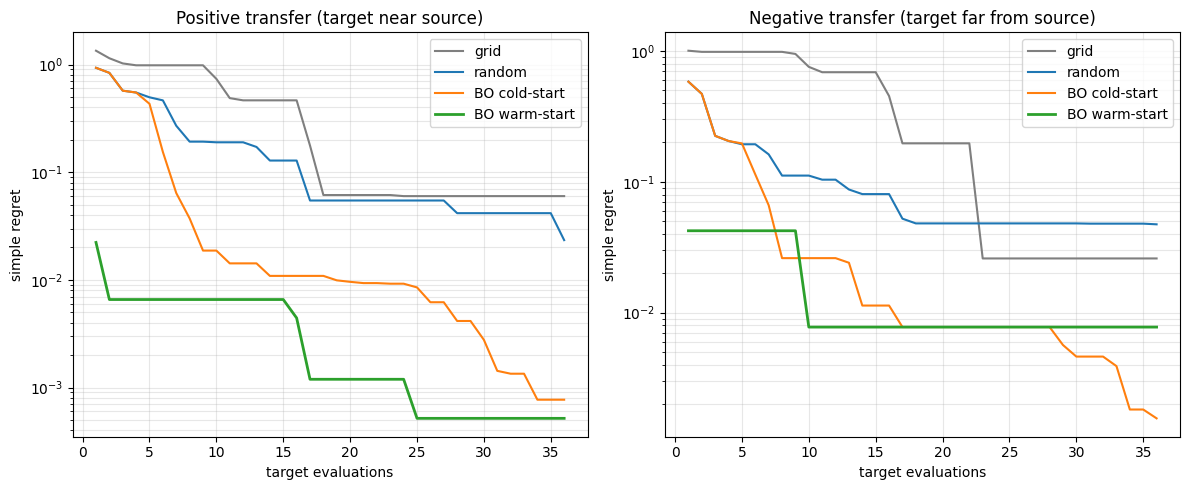

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (title, dd) in zip(axes, [('Positive transfer (target near source)', near),
                                  ('Negative transfer (target far from source)', far)]):
    e = np.arange(1, budget+1)
    ax.plot(e, dd['grid'], '-',  color='C7', label='grid')
    ax.plot(e, dd['rand'], '-',  color='C0', label='random')
    ax.plot(e, dd['cold'], '-',  color='C1', label='BO cold-start')
    ax.plot(e, dd['warm'], '-',  color='C2', lw=2, label='BO warm-start')
    ax.set_yscale('log')
    ax.set_xlabel('target evaluations'); ax.set_ylabel('simple regret')
    ax.set_title(title); ax.legend(); ax.grid(alpha=.3, which='both')
plt.tight_layout(); plt.show()

## 4. 결과 해석

1. **양의 전이 (near)**: target 최적점이 source와 가까우면 **warm-start BO가 초반부터 낮은 regret** 을 보인다.
   source 격자에서 이미 유망 영역을 알고 있어 EI가 첫 평가부터 좋은 점을 찍는다 — 적은 target 평가로 수렴.
2. **cold-BO vs 무작위/격자**: cold-start BO도 평가가 쌓이면 random·grid를 앞선다. grid는 축당 해상도가
   $\sqrt{36}=6$ 로 고정돼 최적점을 격자 사이로 놓치기 쉽고, random은 분산이 크다.
3. **음의 전이 (far)**: target 최적점이 source와 멀면 warm-start는 source가 알던 영역으로 빠르게 내려가
   그럴듯한 값에서 **정체(anchoring)** 된다. 잘못된 사전지식이 EI를 source 최적 근방에 묶어 두어 target의
   진짜 최적점을 충분히 탐색하지 못하고, 결국 **최종 regret이 cold보다 나빠진다**(표에서 warm 7.8e-3 vs cold 1.6e-3).
   이것이 negative transfer의 전형적 형태다 — 초반이 아니라 *수렴값*에서 손해를 본다.
4. **시사점**: 전이의 이득은 **도메인 유사도**에 달려 있다. 유사하면 warm-start가 탐색비용을 크게 아끼지만,
   유사도가 낮으면 사전지식의 가중치를 낮추거나(넓은 사전) cold로 시작하는 편이 안전하다.

> **결론**: 하이퍼파라미터도 "**전이 후 재탐색**" 이 원칙이다. warm-start BO는 유사 도메인에서 강력하지만,
> 음의 전이 가능성 때문에 **탐색 자체는 target 데이터로 계속 갱신**되어야 한다.

**단원 마무리** — Problem 1·2·3을 통해 §14.3의 완성된 파이프라인이 새 도메인으로 갈 때
**복잡도 재선택 · 불확실성 재보정 · 하이퍼파라미터 재탐색** 세 가지를 모두 다시 손봐야 함을 확인했다.
관통하는 뿌리는 변함없이 **편향–분산 트레이드오프와 불확실성의 정량화**다.